Step 1 — Import libraries and load dataset

---



In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

titanic_df = sns.load_dataset("titanic")

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Step 2 — Check the dataset



In [117]:
titanic_df.shape

(891, 15)

In [118]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [119]:
titanic_df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Step 3 — Check missing values

In [120]:
titanic_df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Step 4 — Preprocessing

Fill missing values

In [121]:
titanic_df["age"] = titanic_df["age"].fillna(
    titanic_df["age"].mean()
)

titanic_df["embarked"] = titanic_df["embarked"].fillna(
    titanic_df["embarked"].mode()[0]
)

titanic_df["embark_town"] = titanic_df["embark_town"].fillna(
    titanic_df["embark_town"].mode()[0]
)

Remove deck

In [122]:
titanic_df = titanic_df.drop("deck", axis=1)

Check again

In [123]:
titanic_df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


5. Feature engineering

Create family size

In [124]:
titanic_df["family_size"] = (
    titanic_df["sibsp"] + titanic_df["parch"] + 1
)

Log transform fare

In [125]:
titanic_df["fare_log"] = np.log1p(
    titanic_df["fare"]
)

Check the new columns

In [126]:
titanic_df[
    ["sibsp", "parch", "family_size", "fare", "fare_log"]
].head()

,sibsp,parch,family_size,fare,fare_log
0,1,0,2,7.2500,2.110213
1,1,0,2,71.2833,4.280593
2,0,0,1,7.9250,2.188856
3,1,0,2,53.1000,3.990834
4,0,0,1,8.0500,2.202765


Step 6 — Chart 1: Survival Count

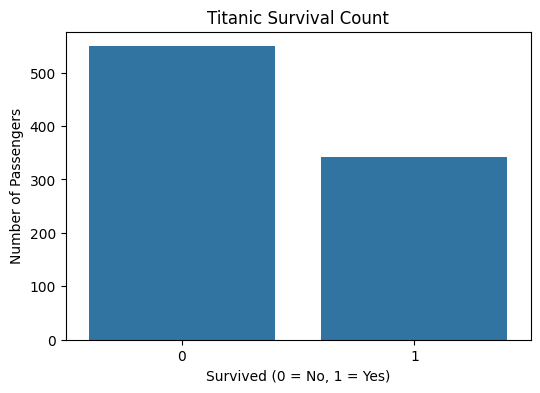

In [127]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_df,
    x="survived"
)

plt.title("Titanic Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

Observation

More passengers died than survived on the Titanic.

📊 Step 7 — Chart 2: Survival by Gender

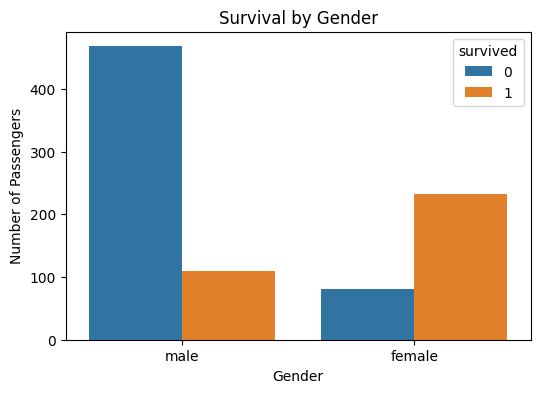

In [128]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_df,
    x="sex",
    hue="survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

Observation

Female passengers had a much higher survival rate than male passengers.

Step 8 — Chart 3: Age Distribution


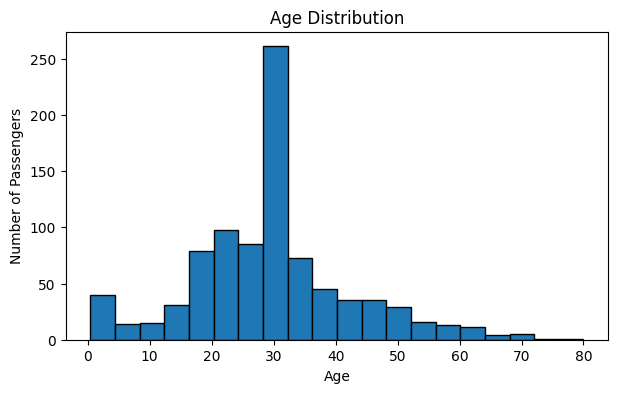

In [129]:
plt.figure(figsize=(7, 4))

plt.hist(
    titanic_df["age"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

Observation

Most passengers were young or middle-aged adults, with fewer children and elderly passengers.

Step 9 — Chart 4: Survival by Passenger Class

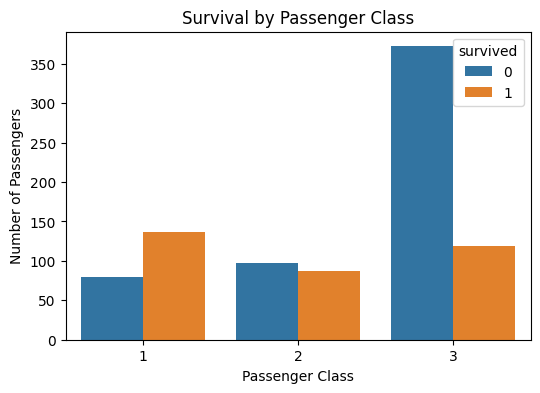

In [130]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_df,
    x="pclass",
    hue="survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

Observation

First-class passengers had better survival outcomes than second- and third-class passengers.

Step 10 — Chart 5: Fare Distribution

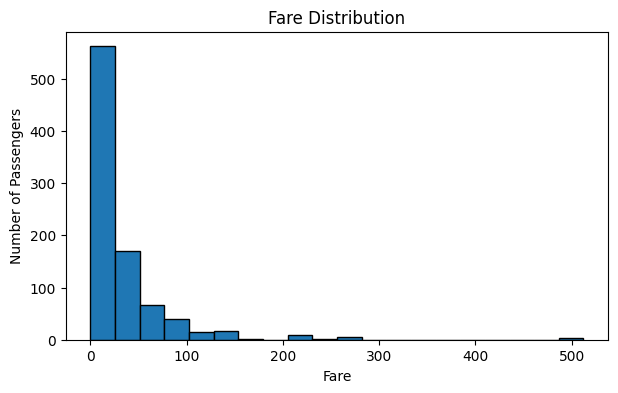

In [131]:
plt.figure(figsize=(7, 4))

plt.hist(
    titanic_df["fare"],
    bins=20,
    edgecolor="black"
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

Observation

Most passengers paid relatively low fares, while a small number paid very high fares.

Step 11 — Chart 6: Survival by Embarkation Port

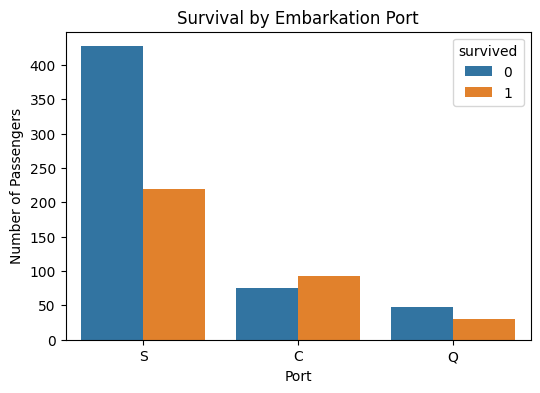

In [132]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=titanic_df,
    x="embarked",
    hue="survived"
)

plt.title("Survival by Embarkation Port")
plt.xlabel("Port")
plt.ylabel("Number of Passengers")

plt.show()

Observation

Southampton had the largest number of passengers and therefore the highest overall number of survivors and deaths.
Port names:

C = Cherbourg
Q = Queenstown
S = Southampton

Step 12 — Chart 7: Family Size Distribution

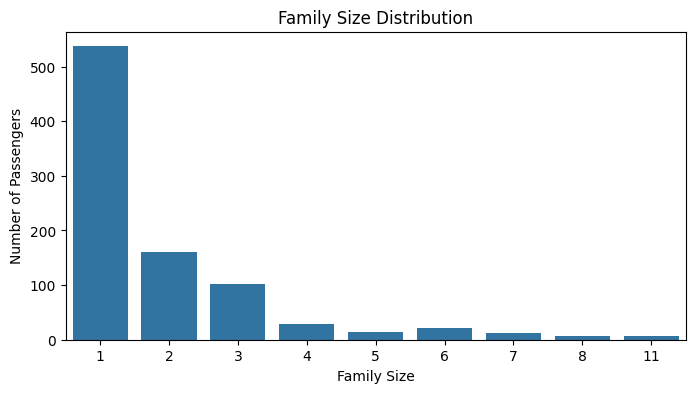

In [133]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=titanic_df,
    x="family_size"
)

plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

plt.show()

Observation

Most passengers traveled alone or with a small family.

Step 13 — Chart 8: Survival Rate by Family Size

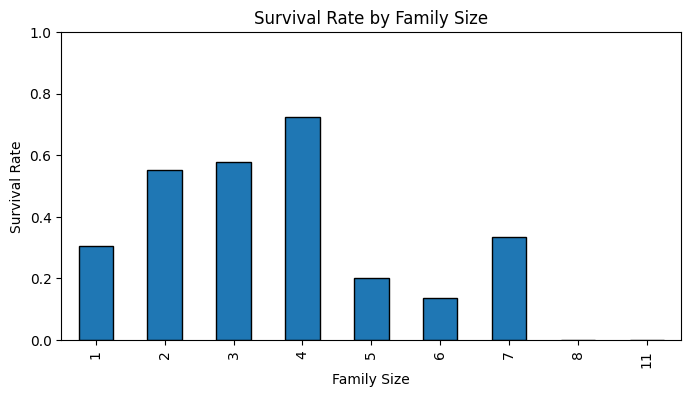

In [134]:
plt.figure(figsize=(8, 4))

family_survival = titanic_df.groupby(
    "family_size"
)["survived"].mean()

family_survival.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.ylim(0, 1)

plt.show()

Observation

Passengers traveling with small families generally had better survival rates than passengers traveling alone or in very large groups.

Step 14 — Chart 9: Survival Rate by Age Group

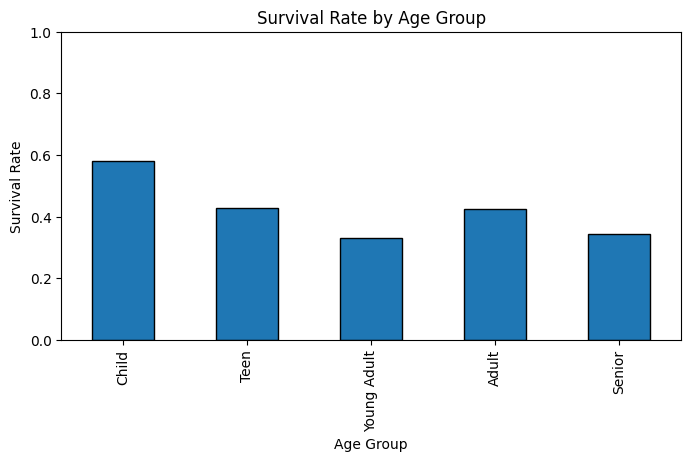

In [135]:
plt.figure(figsize=(8, 4))

titanic_df["age_group"] = pd.cut(
    titanic_df["age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=[
        "Child",
        "Teen",
        "Young Adult",
        "Adult",
        "Senior"
    ]
)

age_survival = titanic_df.groupby(
    "age_group",
    observed=False
)["survived"].mean()

age_survival.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.ylim(0, 1)

plt.show()

Survival rates were different across age groups, with children generally having better survival chances than some adult groups.

Step 15 — Chart 10: Correlation Heatmap

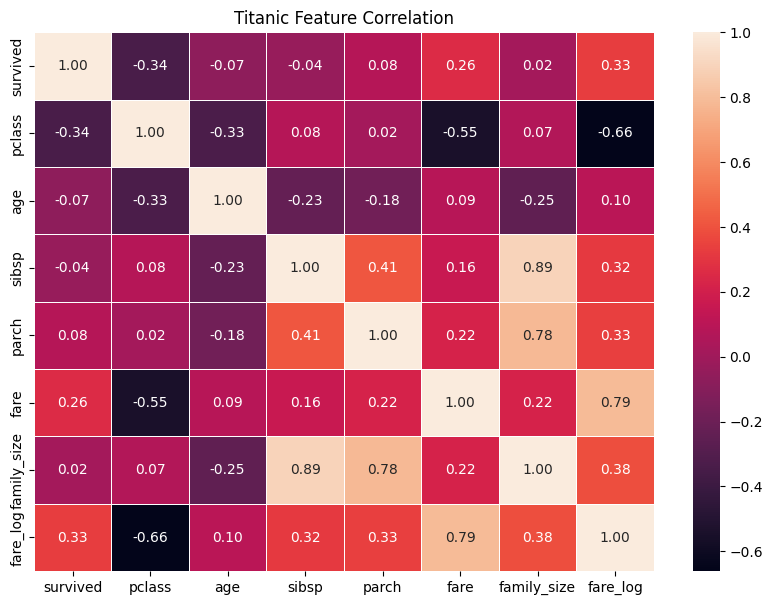

In [136]:
plt.figure(figsize=(10, 7))

numeric_df = titanic_df.select_dtypes(
    include=np.number
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Titanic Feature Correlation")

plt.show()

Observation

The heatmap shows that several passenger features, such as class and fare, have noticeable relationships with survival.

Overall observation from the 10 charts

The Titanic charts show that survival was strongly associated with passenger characteristics. Female passengers and first-class passengers generally had better survival outcomes, while male and third-class passengers had higher death rates. Most passengers were young or middle-aged adults, and most traveled alone or with small families. The fare distribution also shows that most passengers paid relatively low fares. Overall, gender, passenger class, age, fare, and family size provide useful information for predicting Titanic survival.

Step 16 — Prepare Data for Machine Learning

Now we separate:
y = target → what we want to predict
X = features → information used to make the prediction

In [137]:
y = titanic_df["survived"]

X = titanic_df[
    [
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare_log",
        "embarked",
        "alone",
        "family_size"
    ]
]

X.head()

,pclass,sex,age,sibsp,parch,fare_log,embarked,alone,family_size
0,3,male,22.0,1,0,2.110213,S,False,2
1,1,female,38.0,1,0,4.280593,C,False,2
2,3,female,26.0,0,0,2.188856,S,True,1
3,1,female,35.0,1,0,3.990834,S,False,2
4,3,male,35.0,0,0,2.202765,S,True,1


Step 17 — Convert categorical data into numbers USING ONE HOT ENCODING TECHNIQUE

sex and embarked contain text, so we convert them into numerical columns.

drop_first=True removes one category from each categorical variable to avoid unnecessary duplicate information.

In [138]:
X = pd.get_dummies(
    X,
    columns=["sex", "embarked"],
    drop_first=True
)

X.head()

,pclass,age,sibsp,parch,fare_log,alone,family_size,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,2.110213,False,2,True,False,True
1,1,38.0,1,0,4.280593,False,2,False,False,False
2,3,26.0,0,0,2.188856,True,1,False,False,True
3,1,35.0,1,0,3.990834,False,2,False,False,True
4,3,35.0,0,0,2.202765,True,1,True,False,True


Step 18 — Split the data

We'll use:

80% training
20% testing

In [139]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Check the sizes:

In [140]:
X_train.shape, X_test.shape

((712, 10), (179, 10))

Step 19 — Train the Decision Tree

In [141]:
dtc = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4
)

dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

Step 20 — Make predictions

The model uses X_test to predict whether each passenger survived.

In [142]:
y_pred = dtc.predict(X_test)

y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0])

Step 21 — Check Accuracy

In [143]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

accuracy

0.7988826815642458

To see the accuracy as a percentage:

In [144]:
accuracy * 100

79.88826815642457

Confusion matrix

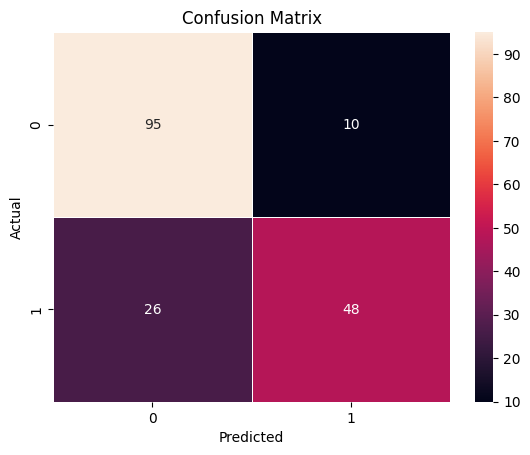

In [145]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    linewidths=0.5
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification report:

Task for weekend:
1)study about standard deviation and variance
2)max depth ,max samples, study((max_depth=5, min_samples_leaf=4, min_samples_split=10, hyper parameters)
3)Find the precision recall and f1 score(make function and call it)
4) make a github profile
5)try to increase the accuracy using the hyper parameters
85% accuracy needed and need to justify why?


Variance and standard deviation are both used to measure how spread out data is. Variance is calculated using squared differences from the mean, while standard deviation is the square root of variance. Variance is important in machine learning because some methods use squared variation to find patterns in data. For example, PCA (Principal Component Analysis) uses variance to find the most important directions of variation and can reduce many features into fewer components. Standard deviation is easier for us to understand because it is in the same unit as the original data. For example, if we are measuring age, the standard deviation is measured in years. Therefore, both variance and standard deviation are useful: variance is useful in mathematical methods, while standard deviation is easier to interpret.**


**Hyperparameters**
→ Settings we choose to control how the model works.

**Why use them?**
→ They help control the tree and reduce overfitting, which can improve accuracy.

**max_depth = 5**
→ The tree can grow up to 5 levels.

**min_samples_leaf = 4**
→ Each final group must have at least 4 samples.

**min_samples_split = 10**
→ A group needs at least 10 samples before it can split.



In [146]:
# Create the Decision Tree
dtc = DecisionTreeClassifier(
    max_depth=5,           # Maximum depth of the tree
    min_samples_leaf=4,    # Minimum 4 samples in each leaf
    min_samples_split=10,  # Minimum 10 samples needed to split
    random_state=42        # Gives the same result each time
)

# Train the model
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)


Suppose:

* **40 people actually survived**
* Your model predicted **30 people survived**
* **24 predictions were correct**

Now look at the denominator:

**Precision:**

> Out of the **30 people I predicted survived**, how many were correct?

`24 ÷ 30 = 80%`

**Recall:**

> Out of the **40 people who actually survived**, how many did I find?

`24 ÷ 40 = 60%`

### 🧠 Super easy trick

**Precision → Prediction**

> "I **predicted** 30. How many were correct?"

**Recall → Real/Actual**

> "There were **actually** 40. How many did I find?"

PRECISION → Predicted positive → How many were correct?

RECALL → Actual positive → How many did I find?
```

That's the main difference. **The numerator can be the same, but the denominator is different.**


In [147]:
# Function to calculate Precision, Recall and F1 Score
# **TP** → Predicted survived and actually survived.

# **FP** → Predicted survived but actually did not survive.

# **FN** → Actually survived but predicted did not survive.



def calculate_metrics(TP, FP, FN):

    # Precision
    precision = TP / (TP + FP)

    # Recall
    recall = TP / (TP + FN)

    # F1 Score
    f1 = 2 * (precision * recall) / (precision + recall)

    return precision, recall, f1

In [148]:
# Example values

TP = 24
FP = 6
FN = 16

precision, recall, f1 = calculate_metrics(TP, FP, FN)

precision, recall, f1

(0.8, 0.6, 0.6857142857142857)

In [149]:
# Import the metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Create a function
def get_metrics(y_test, y_pred):
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return precision, recall, f1

# Call the function
precision, recall, f1 = get_metrics(y_test, y_pred)

# Show the results
precision, recall, f1

(0.8275862068965517, 0.6486486486486487, 0.7272727272727273)

In [150]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

for depth in range(1, 15):

    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=4,
        min_samples_split=10,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(depth, accuracy)

1 0.7821229050279329
2 0.7653631284916201
3 0.7988826815642458
4 0.7988826815642458
5 0.7988826815642458
6 0.8324022346368715
7 0.8156424581005587
8 0.8379888268156425
9 0.8379888268156425
10 0.8435754189944135
11 0.8435754189944135
12 0.8324022346368715
13 0.8324022346368715
14 0.8324022346368715


Depth represents the maximum number of levels in a Decision Tree. I tested different depths from 8 to 20. Depth 10 gave me the highest accuracy of 0.84357, or 84.357%. This means the tree was able to learn useful patterns from the Titanic data without becoming too simple or too complex. I chose depth 10 because it gave the best test accuracy among the depths I tested.

